## 2025 GVA Prediction Estimates

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

import warnings
warnings.filterwarnings("ignore")  

In [3]:

gva_df = pd.read_csv('GVA estimation (1998-2023).csv')
features_df = pd.read_csv('features.csv')

# Get unique LSOA codes from features.csv
lsoa_codes = features_df['LSOA21CD'].unique()

# Filter GVA data to only include LSOA codes from features.csv
filtered_gva = gva_df[gva_df['LSOA code'].isin(lsoa_codes)]


filtered_gva = filtered_gva.rename(columns={
    "LSOA code": "LSOA21CD",
    "LSOA name": "LSOA21NM"
})

# Save to a new CSV file
filtered_gva.to_csv('GVA_filtered_by_features.csv', index=False)



print(f"Total GVA rows: {len(gva_df)}")
print(f"Unique LSOA codes in features.csv: {len(lsoa_codes)}")
print(f"Filtered GVA rows: {len(filtered_gva)}")
print(filtered_gva)

Total GVA rows: 32844
Unique LSOA codes in features.csv: 1125
Filtered GVA rows: 1024
        LSOA21CD               LSOA21NM   LAD code          LAD name ITL code  \
24344  E01016252  Bracknell Forest 001C  E06000036  Bracknell Forest      TLJ   
24345  E01016253  Bracknell Forest 001D  E06000036  Bracknell Forest      TLJ   
24348  E01016185  Bracknell Forest 002B  E06000036  Bracknell Forest      TLJ   
24350  E01016187  Bracknell Forest 002D  E06000036  Bracknell Forest      TLJ   
24351  E01016188  Bracknell Forest 002E  E06000036  Bracknell Forest      TLJ   
...          ...                    ...        ...               ...      ...   
30617  E01032712           Swindon 027E  E06000030           Swindon      TLK   
30618  E01015471           Swindon 028A  E06000030           Swindon      TLK   
30620  E01015512           Swindon 028C  E06000030           Swindon      TLK   
30621  E01015518           Swindon 028D  E06000030           Swindon      TLK   
30622  E01032710       

In [4]:
year_columns = [col for col in filtered_gva.columns if col.isdigit()]  
years = np.array([int(year) for year in year_columns])  

print(f"Rows (LSOAs) : {len(filtered_gva)}")
print(f"Years available: {years[0]} to {years[-1]}")   
print(f"Year columns: {list(year_columns)}") 

Rows (LSOAs) : 1024
Years available: 1998 to 2023
Year columns: ['1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']


In [5]:
def predict_lsoa(row_values, train_years, predict_year):
    # Prepare the training data
    X_train = np.array(train_years).reshape(-1, 1)
    y_train = np.array(row_values).reshape(-1, 1)

    # Create and fit the linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict for the specified year
    predicted_value = model.predict(np.array([[predict_year]]))

    return predicted_value[0][0]

In [6]:
train_year_columns = [col for col in year_columns if int(col) <= 2022]
train_years = np.array([int(year) for year in train_year_columns])

predicted_2023 = []
actual_2023 = []

for _, row in filtered_gva.iterrows():
    train_values = row[train_year_columns].values.astype(float)
    actual_value = float(row['2023'])

    predicted_value = predict_lsoa(train_values, train_years, 2023)
    predicted_2023.append(predicted_value)
    actual_2023.append(actual_value)

predicted_2023 = np.array(predicted_2023)
actual_2023 = np.array(actual_2023)

In [10]:
mae = mean_absolute_error(actual_2023, predicted_2023)
mape = mean_absolute_percentage_error(actual_2023, predicted_2023)
r2 = r2_score(actual_2023, predicted_2023)
rmse = np.sqrt(np.mean((actual_2023 - predicted_2023) ** 2))
bias = np.mean(predicted_2023 - actual_2023)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}")
print(f"R-squared (R2): {r2}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Bias: {bias}")

print("\n Interpretation:")
if mape < 10:
    print(f"  MAPE {mape:.1f}% < 10% → EXCELLENT accuracy, model is reliable for 2025 prediction.")
elif mape < 20:
    print(f"  MAPE {mape:.1f}% is moderate. Predictions carry some uncertainty.")
else:
    print(f"  MAPE {mape:.1f}% > 20% → High error. Use 2025 predictions with caution.")
 
if r2 > 0.85:
    print(f"  R² {r2:.4f} → Model explains most variance. Good linear trend fit.")
elif r2 > 0.6:
    print(f"  R² {r2:.4f} → Moderate fit.")
else:
    print(f"  R² {r2:.4f} → Poor linear fit. Consider non-linear models.")



Mean Absolute Error (MAE): 17.404009345703123
Mean Absolute Percentage Error (MAPE): 0.18194517896304335
R-squared (R2): 0.9075400502008738
Root Mean Squared Error (RMSE): 80.26884108739368
Bias: -9.745082607421892

 Interpretation:
  MAPE 0.2% < 10% → EXCELLENT accuracy, model is reliable for 2025 prediction.
  R² 0.9075 → Model explains most variance. Good linear trend fit.


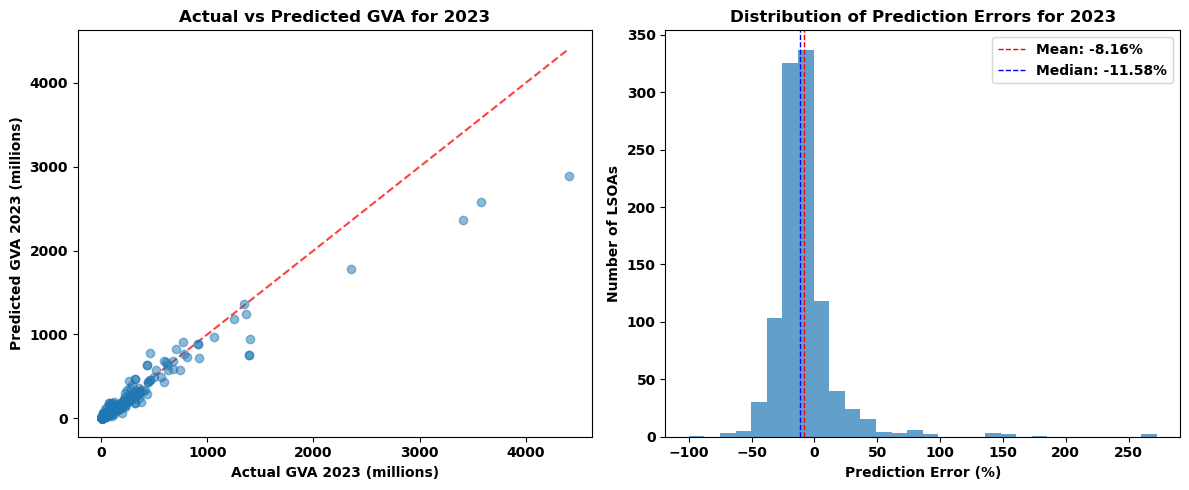

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(actual_2023, predicted_2023, alpha=0.5)
lims = [min(min(actual_2023), min(predicted_2023)), max(max(actual_2023), max(predicted_2023))]
ax1.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
ax1.set_xlabel('Actual GVA 2023 (millions)')
ax1.set_ylabel('Predicted GVA 2023 (millions)')
ax1.set_title('Actual vs Predicted GVA for 2023')

# Error distribution
errors = ((predicted_2023 - actual_2023) / actual_2023) * 100
ax2 = axes[1]
ax2.hist(errors, bins=30, alpha=0.7)
ax2.axvline(np.mean(errors), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(errors):.2f}%')
ax2.axvline(np.median(errors), color='blue', linestyle='dashed', linewidth=1, label=f'Median: {np.median(errors):.2f}%')
ax2.set_xlabel('Prediction Error (%)')
ax2.set_ylabel('Number of LSOAs')
ax2.set_title('Distribution of Prediction Errors for 2023')
ax2.legend()
plt.tight_layout()
plt.savefig('gva_prediction_2023.png')
plt.show()


In [12]:
all_years_mask = years <= 2023
all_years = years[all_years_mask]

predicted_2025 = []

for _, row in filtered_gva.iterrows():
    train_values = row[train_year_columns].values.astype(float)
    predicted_value = predict_lsoa(train_values, train_years, 2025)
    predicted_2025.append(predicted_value)

predicted_2025 = np.array(predicted_2025)

In [14]:
results = filtered_gva[["LSOA21CD", "LSOA21NM"]].copy()
results["GVA_2023_actual"] = actual_2023
results["GVA_2023_predicted"] = predicted_2023.round(3)
# results["GVA_2023_error_percent"] = (((predicted_2023 - actual_2023) / actual_2023) * 100).round(2)
results["GVA_2025_predicted"] = predicted_2025.round(3)

results.to_csv('gva_2025_predictions_estimates.csv', index=False)
print("2025 GVA predictions saved to 'gva_2025_predictions_estimates.csv'")
print(results.head())

2025 GVA predictions saved to 'gva_2025_predictions_estimates.csv'
        LSOA21CD               LSOA21NM  GVA_2023_actual  GVA_2023_predicted  \
24344  E01016252  Bracknell Forest 001C           29.370              53.576   
24345  E01016253  Bracknell Forest 001D           11.642               9.285   
24348  E01016185  Bracknell Forest 002B          460.353             784.357   
24350  E01016187  Bracknell Forest 002D           28.120              21.854   
24351  E01016188  Bracknell Forest 002E           26.325              14.216   

       GVA_2025_predicted  
24344              53.060  
24345               9.577  
24348             842.259  
24350              23.060  
24351              14.663  
